<a href="https://colab.research.google.com/github/darrickpang/Email/blob/master/Face_isolation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install opencv-python face_recognition numpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.1/100.1 MB 9.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for face-recognition-models: filename=face_recognition_models-0.3.0-py2.py3-none-any.whl size=100566166 sha256=2270473ce483a7edd712988ef1dd9cbb492abe311abb5ff0cfcb39b87dbdb716
  Stored in directory: /root/.cache/pip/wheels/8f/47/c8/f44c5aebb7507f7c8a2c0bd23151d732d0f0bd6884ad4ac635
Successfully built face-recognition-models


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import face_recognition

suspect_img = face_recognition.load_image_file("/content/drive/MyDrive/20251217_142159.jpg")

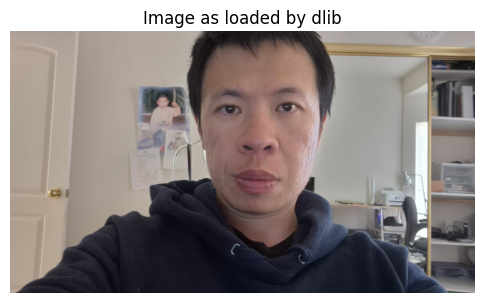

Image shape: (1908, 3392, 3)


In [ ]:
import matplotlib.pyplot as plt
import face_recognition

img = face_recognition.load_image_file("/content/drive/MyDrive/20251217_142159.jpg")

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")
plt.title("Image as loaded by dlib")
plt.show()

print("Image shape:", img.shape)

In [ ]:
import face_recognition

suspect_img = face_recognition.load_image_file("/content/drive/MyDrive/20251217_142159.jpg")

face_locations = face_recognition.face_locations(
    suspect_img,
    number_of_times_to_upsample=2,  # 🔥 key fix
    model="hog"                     # hog works best on Colab CPU
)

suspect_encodings = face_recognition.face_encodings(
    suspect_img,
    face_locations
)

print("Detected faces:", len(face_locations))
print(face_locations)

if len(suspect_encodings) > 0:
    suspect_encoding = suspect_encodings[0]
    print("Face encoding successfully extracted.")
else:
    print("Error: No face found in the suspect image. Please check the image path or content.")
    suspect_encoding = None # Or handle this case as appropriate

ref_encoding = face_recognition.face_encodings(suspect_img)[0]

Detected faces: 1
[(309, 2296, 1303, 1302)]
Face encoding successfully extracted.


In [ ]:
import cv2

video_path = "/content/drive/MyDrive/Copy of WIN_20251218_09_20_50_Pro.mp4"
cap = cv2.VideoCapture(video_path)

print("FPS:", cap.get(cv2.CAP_PROP_FPS))

FPS: 30.057159057872646


In [ ]:
import numpy as np

faces_extracted = []
frame_count = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    frame_count += 1

    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    face_locations = face_recognition.face_locations(
        rgb,
        number_of_times_to_upsample=1,
        model="hog"
    )

    face_encodings = face_recognition.face_encodings(
        rgb,
        face_locations
    )

    for (top, right, bottom, left), enc in zip(face_locations, face_encodings):
        distance = np.linalg.norm(enc - ref_encoding)

        if distance < 0.6:
            face_crop = frame[top:bottom, left:right]
            faces_extracted.append(face_crop)

cap.release()

print("Total faces extracted:", len(faces_extracted))

Total faces extracted: 22


In [ ]:
import cv2
import face_recognition
import numpy as np

tracker = None
tracking = False
VERIFY_EVERY = 15   # frames
frame_idx = 0

In [ ]:
cap = cv2.VideoCapture("/content/drive/MyDrive/Copy of WIN_20251218_09_20_50_Pro.mp4")

tracked_boxes = []

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    frame_idx += 1
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # 🔹 STEP A: If NOT tracking → detect + identify
    if not tracking:
        face_locations = face_recognition.face_locations(rgb, model="hog")
        face_encodings = face_recognition.face_encodings(rgb, face_locations)

        for (top, right, bottom, left), enc in zip(face_locations, face_encodings):
            distance = np.linalg.norm(enc - ref_encoding)

            if distance < 0.6:
                # Initialize tracker
                tracker = cv2.TrackerCSRT_create()
                bbox = (left, top, right - left, bottom - top)
                tracker.init(frame, bbox)
                tracking = True
                print(f"Tracking started at frame {frame_idx}")
                break

    # 🔹 STEP B: If tracking → update tracker
    else:
        success, bbox = tracker.update(frame)

        if success:
            x, y, w, h = map(int, bbox)
            tracked_boxes.append((frame_idx, x, y, w, h))

            cv2.rectangle(frame, (x,y), (x+w, y+h), (0,255,0), 2)
            cv2.putText(frame, "ME",
                        (x, y-10),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.9, (0,255,0), 2)

            # 🔹 STEP C: Periodic identity re-check
            if frame_idx % VERIFY_EVERY == 0:
                face_crop = rgb[y:y+h, x:x+w]
                encs = face_recognition.face_encodings(face_crop)

                if not encs or np.linalg.norm(encs[0] - ref_encoding) > 0.65:
                    print("Identity lost — re-detecting")
                    tracking = False
                    tracker = None
        else:
            print("Tracking failure — re-detecting")
            tracking = False
            tracker = None

cap.release()

KeyboardInterrupt: 

In [ ]:
import cv2
import face_recognition
import numpy as np

input_video = "/content/drive/MyDrive/Copy of WIN_20251218_09_20_50_Pro.mp4"
output_video = "/content/drive/MyDrive/Copy of WIN_20251218_09_20_50_Pro.mp4"

cap = cv2.VideoCapture(input_video)

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter(output_video, fourcc, fps, (width, height))

In [ ]:
tracker = None
tracking = False
frame_idx = 0
VERIFY_EVERY = 15

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    frame_idx += 1
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # 🔹 If NOT tracking → detect & identify
    if not tracking:
        face_locations = face_recognition.face_locations(rgb, model="hog")
        face_encodings = face_recognition.face_encodings(rgb, face_locations)

        for (top, right, bottom, left), enc in zip(face_locations, face_encodings):
            distance = np.linalg.norm(enc - ref_encoding)

            if distance < 0.6:
                tracker = cv2.TrackerCSRT_create()
                bbox = (left, top, right - left, bottom - top)
                tracker.init(frame, bbox)
                tracking = True
                break

    # 🔹 If tracking → update tracker
    else:
        success, bbox = tracker.update(frame)

        if success:
            x, y, w, h = map(int, bbox)

            # Draw box + label
            cv2.rectangle(frame, (x, y), (x+w, y+h), (0,255,0), 2)
            cv2.putText(frame, "ME",
                        (x, y-10),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.9, (0,255,0), 2)

            # Periodic identity check
            if frame_idx % VERIFY_EVERY == 0:
                face_crop = rgb[y:y+h, x:x+w]
                encs = face_recognition.face_encodings(face_crop)

                if not encs or np.linalg.norm(encs[0] - ref_encoding) > 0.65:
                    tracking = False
                    tracker = None
        else:
            tracking = False
            tracker = None

    out.write(frame)

cap.release()
out.release()

print("Annotated video saved:", output_video)

Annotated video saved: /content/drive/MyDrive/Copy of WIN_20251218_09_20_50_Pro.mp4


In [ ]:
from IPython.display import Video, display

display(Video(output_video, embed=True))

In [ ]:
from IPython.display import Video, display

display(Video("/content/drive/MyDrive/20200923_180124.mp4", embed=True))